# Assignment 3: Medical Image Generation with Autoencoders
### 2025-2026


## Objectives
 - Understand and apply autoencoders to medical image data  
 - Perform pre-processing on chest X‑ray images  
 - Build and train a **Convolutional Autoencoder** (AE) and a **Variational Autoencoder** (VAE)  
 - Evaluate reconstruction quality and generate synthetic medical images  
 - Analyse the latent space of the VAE

 ## Data

 We use the **PneumoniaMNIST** dataset (a MedMNIST 2D dataset).  
 It contains 5,856 paediatric chest X‑ray images (28×28 grayscale) labelled as Normal (0) or Pneumonia (1).

 Source: [MedMNIST](https://medmnist.com/) (Yang et al., 2021).  
 The dataset is automatically downloaded when using the `medmnist` library.

 ## Instructions
 - Complete the exercises in the provided code cells.  
 - Add your answers to the questions in a separate **Word/PDF report** following the report template.  


### 0. Setup & Dependencies

In [9]:
!pip install -q medmnist scikit-learn scikit-image


### 1. Load and Explore the Chest X‑ray Data

## Exercise 1

 1. Load the PneumoniaMNIST dataset (train+test).  
 2. Combine them into a single set for unsupervised learning (labels are ignored).  
 3. Visualise 16 sample images.  
 4. Answer the questions in your report.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import PneumoniaMNIST, INFO
from tqdm import tqdm

# Define transform: ToTensor converts images to [0, 1] range
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download train & test splits, combine them into one big unsupervised dataset
train_data = PneumoniaMNIST(split='train', download=True, transform=transform)
test_data  = PneumoniaMNIST(split='test',  download=True, transform=transform)
all_data   = ConcatDataset([train_data, test_data])

# get total number of images
print(f'Total images: {len(all_data)}')
# get original image size
img, label = all_data[0]
print(f'Original image shape: {img.shape}')

Total images: 5332
Original image shape: torch.Size([1, 28, 28])


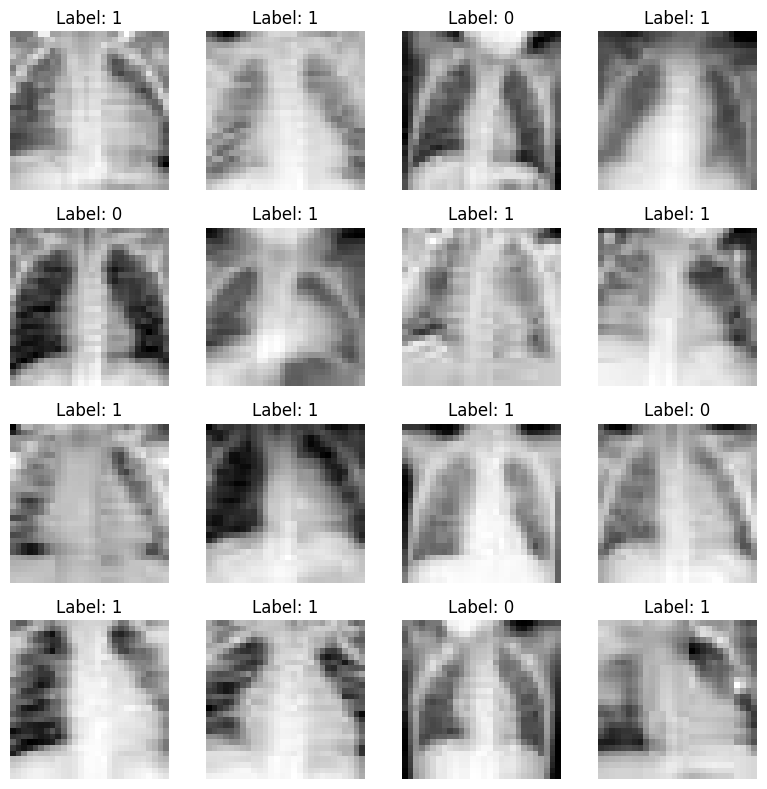

In [11]:
# Visualize 16 sample images
def show_images(dataset, num_images=16):
    loader = DataLoader(dataset, batch_size=num_images, shuffle=True)
    images, labels = next(iter(loader))
    
    plt.figure(figsize=(8, 8))
    for i in range(num_images):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f'Label: {labels[i].item()}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_images(all_data)

### 2. Convolutional Autoencoder (AE)

 Build a CNN‑based autoencoder that compresses a 28×28 image to a latent vector (e.g., dimension 64) and reconstructs it.

## Exercise 2
1. Define the `ConvAutoencoder` class (encoder–decoder).  
2. Train the model with **BCE loss** for 30 epochs (use the whole dataset, no labels).  
3. Plot the training loss curve.  
4. Visualise original vs. reconstructed images from the test split.  
5. Compute the average **SSIM** (Structural Similarity) between original and reconstructed test images (you may use `skimage.measure.compare_ssim`).  
6. Discuss the reconstruction quality.

Epoch [1/30], Loss: 0.6680


Epoch [2/30], Loss: 0.6420


Epoch [3/30], Loss: 0.6350


Epoch [4/30], Loss: 0.6322


Epoch [5/30], Loss: 0.6305


...

Epoch [26/30], Loss: 0.6257


Epoch [27/30], Loss: 0.6256


Epoch [28/30], Loss: 0.6256


Epoch [29/30], Loss: 0.6255


Epoch [30/30], Loss: 0.6255


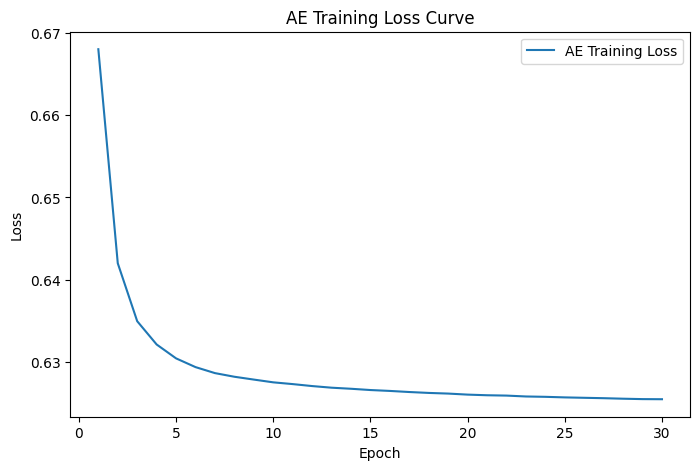

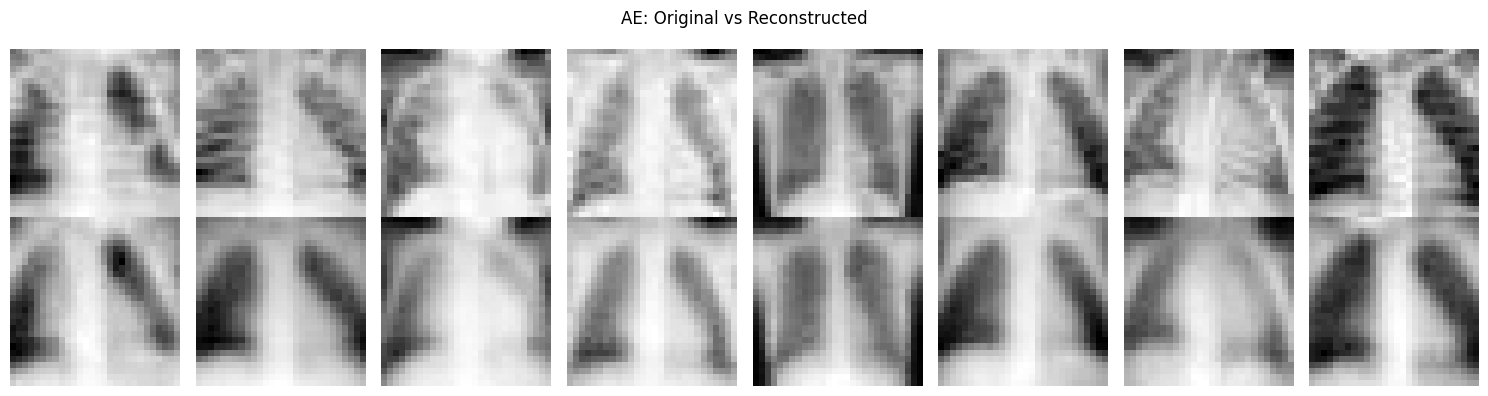

Average SSIM (100 test images): 0.9124


[W516 14:29:58.543574467 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:29:58.555030708 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:29:58.564652294 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:29:58.564778461 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:29:58.565426759 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:29:58.568070513 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:29:58.569090343 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:29:58.569744401 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:29:58.570442990 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:29:58.581928878 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:2

In [12]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(ConvAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

# Training Hyperparameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent_dim = 64
learning_rate = 1e-3
batch_size = 64
epochs = 30

model_ae = ConvAutoencoder(latent_dim).to(device)
optimizer = optim.Adam(model_ae.parameters(), lr=learning_rate)
criterion = nn.BCELoss()

train_loader = DataLoader(all_data, batch_size=batch_size, shuffle=True)

# Training Loop
loss_history_ae = []
for epoch in range(epochs):
    model_ae.train()
    running_loss = 0.0
    for images, _ in tqdm(train_loader, desc=f'AE Epoch {epoch+1}/{epochs}', leave=False):
        images = images.to(device)
        
        optimizer.zero_grad()
        outputs = model_ae(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(all_data)
    loss_history_ae.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history_ae, label='AE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('AE Training Loss Curve')
plt.legend()
plt.show()

from skimage.metrics import structural_similarity as ssim

def evaluate_ae(model, dataset, num_samples=8):
    model.eval()
    loader = DataLoader(dataset, batch_size=num_samples, shuffle=True)
    images, _ = next(iter(loader))
    images = images.to(device)
    
    with torch.no_grad():
        reconstructed = model(images)
    
    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()
    
    plt.figure(figsize=(15, 4))
    for i in range(num_samples):
        # Original
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel('Original')
        
        # Reconstructed
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel('Reconstructed')
    plt.suptitle('AE: Original vs Reconstructed')
    plt.tight_layout()
    plt.show()

    # Calculate average SSIM on a larger subset
    ssim_scores = []
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)
    for i, (img, _) in enumerate(test_loader):
        if i >= 100: break # Use 100 images for speed
        img = img.to(device)
        with torch.no_grad():
            rec = model(img)
        img_np = img.cpu().squeeze().numpy()
        rec_np = rec.cpu().squeeze().numpy()
        score = ssim(img_np, rec_np, data_range=1.0)
        ssim_scores.append(score)
    
    print(f'Average SSIM (100 test images): {np.mean(ssim_scores):.4f}')

evaluate_ae(model_ae, test_data)

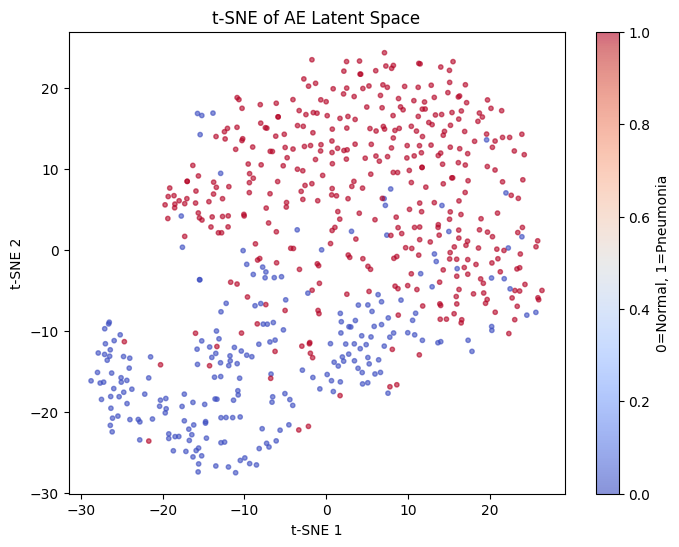

In [13]:
from sklearn.manifold import TSNE

# Extract latent vectors from the AE encoder
model_ae.eval()
latent_list, label_list = [], []
test_loader_tsne = DataLoader(test_data, batch_size=64, shuffle=False)

with torch.no_grad():
    for imgs, labels in test_loader_tsne:
        latent = model_ae.encoder(imgs.to(device))   # AE encoder outputs z directly
        latent_list.append(latent.cpu().numpy())
        label_list.append(labels.numpy().flatten())
        if sum(len(l) for l in label_list) >= 1000:
            break

latent_arr = np.concatenate(latent_list)[:1000]
labels_arr = np.concatenate(label_list)[:1000]

# t-SNE reduction to 2D
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_arr)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1],
                      c=labels_arr, cmap='coolwarm', alpha=0.6, s=10)
plt.colorbar(scatter, label='0=Normal, 1=Pneumonia')
plt.title('t-SNE of AE Latent Space')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

### 3. Variational Autoencoder (VAE)

Transform the AE into a **generative** VAE that can create novel chest X‑rays.

## Exercise 3

  1. Implement the `VAE` class (encoder outputs `mu` and `logvar`; reparameterisation trick).  
  2. Train for 50 epochs using a loss that combines BCE reconstruction and KL divergence.  
  3. Plot the training loss and the separate reconstruction and KL terms (if you wish).  
  4. Compare the reconstruction sharpness with the AE.

  5. Generate 16 synthetic chest X‑rays by sampling from the standard normal prior.  
  6. Perform **latent space interpolation** between two random vectors and visualise the morphing.  
  7. Use **t‑SNE** to visualise the latent `mu` vectors of 1,000 test images, coloured by the (withheld) Normal/Pneumonia label.  
  8. Interpret the t‑SNE plot.

Epoch [10/50]  Total: 506.0395  Recon: 501.5238  KL: 4.5157


Epoch [20/50]  Total: 505.1636  Recon: 500.3062  KL: 4.8574


Epoch [30/50]  Total: 504.8471  Recon: 499.8536  KL: 4.9935


Epoch [40/50]  Total: 504.6524  Recon: 499.6126  KL: 5.0398


Epoch [50/50]  Total: 504.4779  Recon: 499.3463  KL: 5.1316


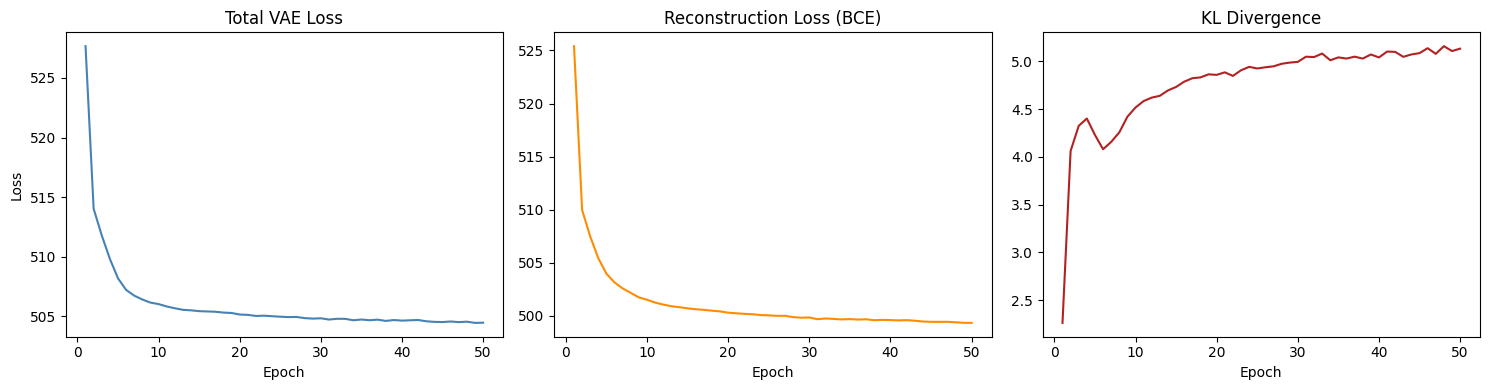

KL term is healthy at 5.1316 — no posterior collapse detected.


In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        # Encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(32 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(32 * 7 * 7, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Training Hyperparameters
model_vae = VAE(latent_dim).to(device)
optimizer_vae = optim.Adam(model_vae.parameters(), lr=learning_rate)
vae_epochs = 50

# Training Loop — track total, reconstruction and KL terms separately
loss_history_vae = []
recon_history_vae = []
kl_history_vae = []

for epoch in range(vae_epochs):
    model_vae.train()
    running_loss  = 0.0
    running_recon = 0.0
    running_kl    = 0.0

    for images, _ in tqdm(train_loader, desc=f'VAE Epoch {epoch+1}/{vae_epochs}', leave=False):
        images = images.to(device)

        optimizer_vae.zero_grad()
        recon_batch, mu, logvar = model_vae(images)

        # Compute terms separately for monitoring
        recon_loss = nn.functional.binary_cross_entropy(recon_batch, images, reduction='sum')
        kl_loss    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss       = recon_loss + kl_loss

        loss.backward()
        optimizer_vae.step()

        running_loss  += loss.item()
        running_recon += recon_loss.item()
        running_kl    += kl_loss.item()

    n = len(all_data)
    loss_history_vae.append(running_loss  / n)
    recon_history_vae.append(running_recon / n)
    kl_history_vae.append(running_kl    / n)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{vae_epochs}]  '
              f'Total: {loss_history_vae[-1]:.4f}  '
              f'Recon: {recon_history_vae[-1]:.4f}  '
              f'KL: {kl_history_vae[-1]:.4f}')

# Plot all three curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(range(1, vae_epochs + 1), loss_history_vae,  color='steelblue')
axes[0].set_title('Total VAE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(range(1, vae_epochs + 1), recon_history_vae, color='darkorange')
axes[1].set_title('Reconstruction Loss (BCE)')
axes[1].set_xlabel('Epoch')

axes[2].plot(range(1, vae_epochs + 1), kl_history_vae,    color='firebrick')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()


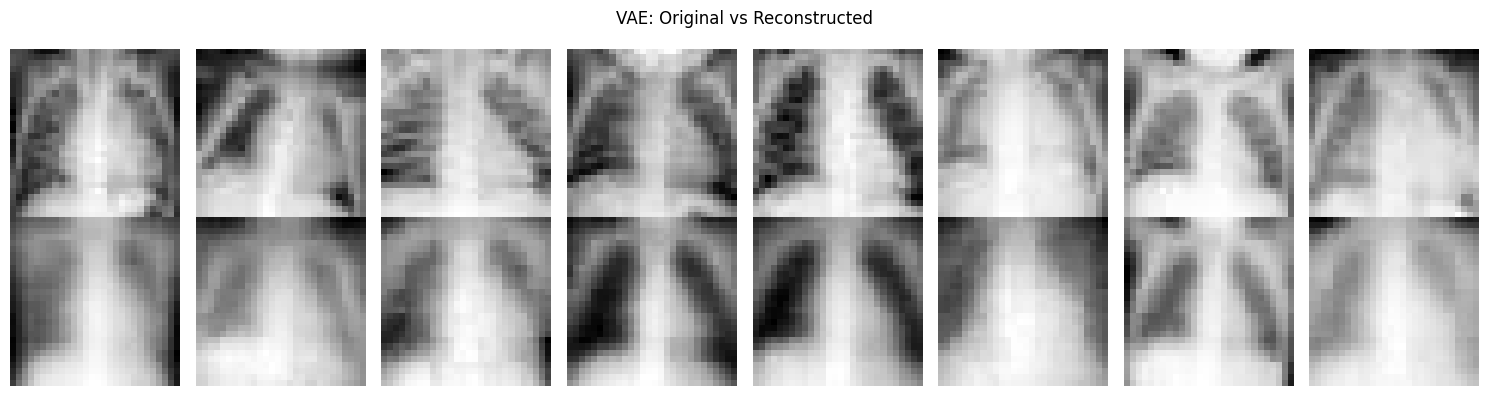

[W516 14:37:08.304414496 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:08.319035898 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:08.350728933 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:08.351167483 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:08.354724847 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:08.355417844 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:08.362793838 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:08.363065072 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:08.369777254 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:08.372550883 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:3

VAE Average SSIM (100 test images): 0.7297


[W516 14:37:09.922870003 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:09.927838133 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:09.928749405 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:09.928894662 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:09.929537422 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:09.929615862 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:09.936960009 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:09.945118249 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:09.946399772 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:37:09.948146490 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W516 14:3

In [15]:
from skimage.metrics import structural_similarity as ssim

def evaluate_vae(model, dataset, num_samples=8):
    model.eval()
    loader = DataLoader(dataset, batch_size=num_samples, shuffle=True)
    images, _ = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        reconstructed, _, _ = model(images)   # VAE returns (recon, mu, logvar)

    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

    plt.figure(figsize=(15, 4))
    for i in range(num_samples):
        # Original
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel('Original')

        # Reconstructed
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel('Reconstructed')

    plt.suptitle('VAE: Original vs Reconstructed')
    plt.tight_layout()
    plt.show()

    # Average SSIM on 100 test images
    ssim_scores = []
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)
    for i, (img, _) in enumerate(test_loader):
        if i >= 100: break
        img = img.to(device)
        with torch.no_grad():
            rec, _, _ = model(img)             # unpack all three outputs
        img_np = img.cpu().squeeze().numpy()
        rec_np = rec.cpu().squeeze().numpy()
        score = ssim(img_np, rec_np, data_range=1.0)
        ssim_scores.append(score)

    print(f'VAE Average SSIM (100 test images): {np.mean(ssim_scores):.4f}')

evaluate_vae(model_vae, test_data)

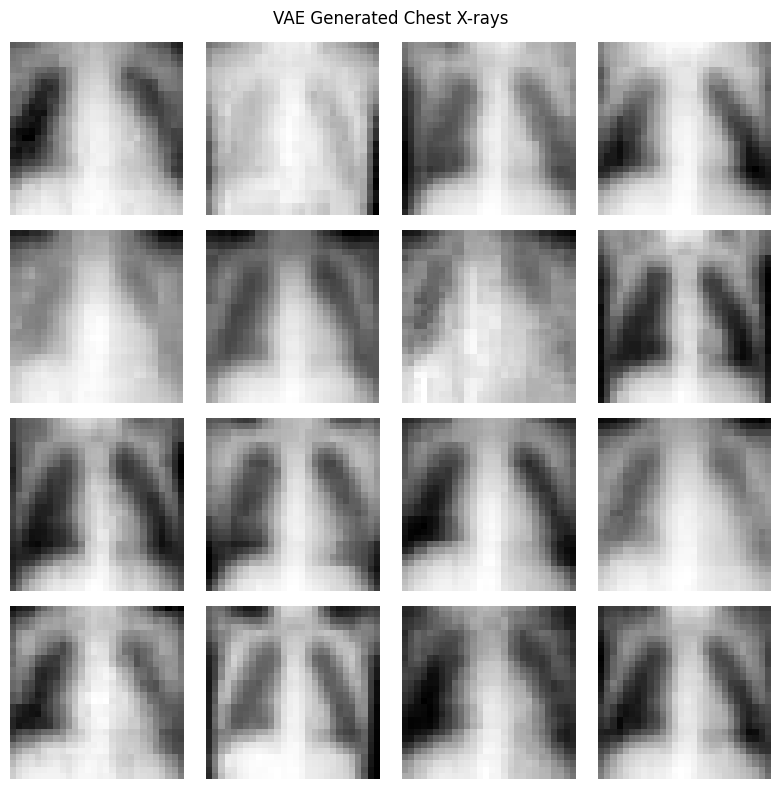

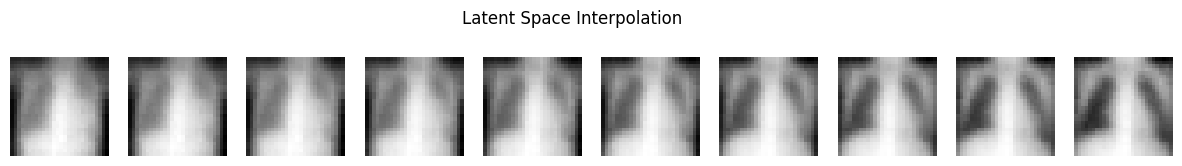

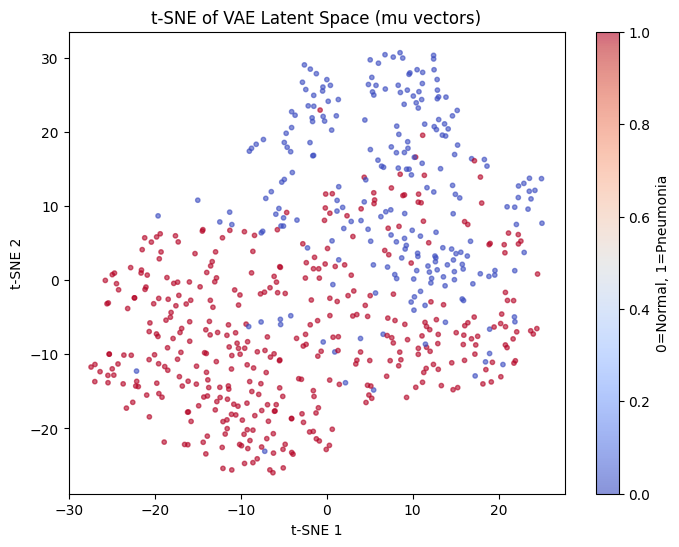

In [16]:
# Generate 16 synthetic images
model_vae.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated = model_vae.decode(z).cpu()

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('VAE Generated Chest X-rays')
plt.tight_layout()
plt.show()

# Latent space interpolation
model_vae.eval()
with torch.no_grad():
    z1 = torch.randn(1, latent_dim).to(device)
    z2 = torch.randn(1, latent_dim).to(device)
    alphas = torch.linspace(0, 1, 10)
    interp_imgs = [model_vae.decode((1 - a.item()) * z1 + a.item() * z2).cpu() for a in alphas]

plt.figure(figsize=(15, 2))
for i, img in enumerate(interp_imgs):
    plt.subplot(1, 10, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('Latent Space Interpolation')
plt.show()

# t-SNE of latent mu vectors
from sklearn.manifold import TSNE

model_vae.eval()
mu_list, label_list = [], []
loader_1000 = DataLoader(test_data, batch_size=64, shuffle=False)
with torch.no_grad():
    for imgs, labels in loader_1000:
        mu, _ = model_vae.encode(imgs.to(device))
        mu_list.append(mu.cpu().numpy())
        label_list.append(labels.numpy().flatten())
        if sum(len(l) for l in label_list) >= 1000:
            break

mu_arr = np.concatenate(mu_list)[:1000]
labels_arr = np.concatenate(label_list)[:1000]

tsne = TSNE(n_components=2, random_state=42)
mu_2d = tsne.fit_transform(mu_arr)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1], c=labels_arr, cmap='coolwarm', alpha=0.6, s=10)
plt.colorbar(scatter, label='0=Normal, 1=Pneumonia')
plt.title('t-SNE of VAE Latent Space (mu vectors)')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.show()